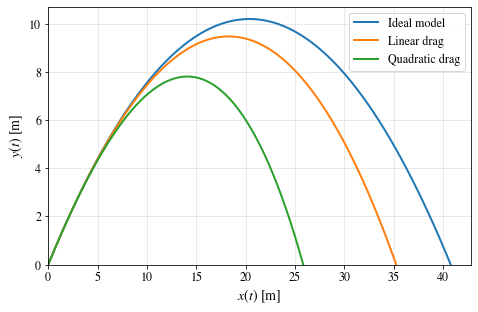

In [12]:
# ============================================================
# Projectile Motion in Python
# Comparison of the three projectile-motion models
# ============================================================

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# Plot style
mpl.rcParams["text.usetex"] = False
mpl.rcParams["font.family"] = "STIXGeneral"
mpl.rcParams["mathtext.fontset"] = "stix"


# Physical parameters (SI units)
g = 9.81            # m/s^2
v0 = 20.0           # m/s
theta_deg = 45.0    # degrees

gamma = 0.08        # 1/s
kappa = 0.02        # 1/m

theta = np.radians(theta_deg)


# Initial conditions
state0 = [
    0.0,
    0.0,
    v0*np.cos(theta),
    v0*np.sin(theta),
]


# Governing equations
def ideal_model(t, state):

    x, y, vx, vy = state

    return [
        vx,
        vy,
        0.0,
        -g,
    ]


def linear_model(t, state):

    x, y, vx, vy = state

    return [
        vx,
        vy,
        -gamma*vx,
        -g-gamma*vy,
    ]


def quadratic_model(t, state):

    x, y, vx, vy = state

    speed = np.hypot(vx, vy)

    return [
        vx,
        vy,
        -kappa*speed*vx,
        -g-kappa*speed*vy,
    ]


# Ground-impact event
def ground_event(t, state):

    if t < 1.0e-8:
        return 1.0

    return state[1]


ground_event.terminal = True
ground_event.direction = -1


# Numerical solution
def solve_trajectory(model):

    solution = solve_ivp(
        model,
        (0.0, 20.0),
        state0,
        events=ground_event,
        max_step=0.02,
        rtol=1e-9,
        atol=1e-11,
    )

    return solution.y[0], solution.y[1]


# Trajectories
x_ideal, y_ideal = solve_trajectory(ideal_model)
x_linear, y_linear = solve_trajectory(linear_model)
x_quadratic, y_quadratic = solve_trajectory(quadratic_model)


# -------- Plot --------

plt.figure(figsize=(6.8, 4.5))

plt.plot(
    x_ideal,
    y_ideal,
    linewidth=2,
    label="Ideal model",
)

plt.plot(
    x_linear,
    y_linear,
    linewidth=2,
    label="Linear drag",
)

plt.plot(
    x_quadratic,
    y_quadratic,
    linewidth=2,
    label="Quadratic drag",
)


# Markers

# (Not included in this overview figure)


# Annotations

# (Not included in this overview figure)


# Axes and ticks

plt.xlabel(r"$x(t)\ \mathrm{[m]}$", fontsize=14)
plt.ylabel(r"$y(t)\ \mathrm{[m]}$", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.xlim(left=0.0)
plt.ylim(bottom=0.0)


# Legend

plt.legend(fontsize=12)
plt.grid(True, alpha=0.35)
plt.tight_layout()


# Save figure

plt.savefig(
    "three_models_comparison.png",
    dpi=400,
    bbox_inches="tight",
)

plt.savefig(
    "three_models_comparison.pdf",
    dpi=400,
    bbox_inches="tight",
)

plt.show()